In [1]:
# Imports
import os
from pathlib import Path
markers = (".git", "Program")
current_dir = Path.cwd()
project_root = next((path for path in (current_dir, *current_dir.parents) if any((path / marker).exists() for marker in markers)), current_dir)
os.chdir(project_root)

from backtest import *
import concurrent.futures
import datetime as dt
from functools import partial
from fundamentals import *
from helper_functions import modify_current_date, get_df, get_excel_filename, get_infix, get_volume5m_data, generate_end_dates, merge_stocks, stock_market
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import multiprocessing
import numpy as np
import pandas as pd
from pandas import ExcelWriter as EW
from plot import *
import random
from scipy.optimize import minimize
from scipy.stats import false_discovery_control, kendalltau, linregress, pearsonr, spearmanr, ttest_ind, wilcoxon
from stock_screener import check_conds_tech, check_conds_fund, EM_rating, get_stock_info, stoploss_target
from technicals import *
from tqdm import tqdm

# Connect to TradingView
from tvDatafeed import TvDatafeed, Interval
tv = TvDatafeed()

# Start of the program
start = dt.datetime.now()

# Index
index_name = "^GSPC"
index_dict = {"^HSI": "HKEX", "^GSPC": "S&P 500", "^IXIC": "NASDAQ Composite"}

# Modify the current date
current_date = modify_current_date(start, index_name)

you are using nologin method, data you access may be limited


In [16]:
# === Select Stock Universe from Excel File ===
# Load pre-screened stocks from the stock screener output file
# Filter for large-cap stocks (market cap > $10B) to ensure liquidity
excel_filename = get_excel_filename("2026-01-10", "^GSPC", index_dict, 252, 90, True)

excel_df = pd.read_excel(excel_filename)
stocks_df = excel_df.loc[excel_df["Market Cap (B, USD)"] > 10, ["Stock", "Long-term RS", "Market Cap (B, USD)"]]
stocks = stocks_df["Stock"].tolist()

Calculating momentum and volatility: 100%|██████████| 81/81 [00:00<00:00, 3143.28it/s]


,Stock,Cluster,Momentum,Volatility,Mean Weekly Return (%),Std Weekly Return (%),This Week Return (%),Z-Score,Vol-adj Momentum
Rank,,,,,,,,,
1,PUK,4,2.017760,0.011713,1.382262,3.444218,3.611369,0.647202,172.268351
2,SAN,4,2.489178,0.014879,1.635219,3.866793,2.140411,0.130649,167.290810
3,BBVA,4,2.251236,0.016666,1.469589,4.049749,1.210552,-0.063964,135.078696
4,ING,4,1.779421,0.013885,1.238564,3.998471,2.397138,0.289754,128.151954
5,MT,5,2.063010,0.016099,1.338892,5.426888,3.886694,0.469477,128.144760
6,BCS,4,1.906225,0.015380,1.331429,3.975747,3.021980,0.425216,123.943066
7,CIB,5,1.983926,0.016396,1.066202,3.792789,3.355912,0.603701,121.000232
8,IONS,5,2.365212,0.019783,2.353696,7.695069,1.887965,-0.060523,119.556747
9,WF,5,1.810252,0.015450,1.212912,3.539188,0.492355,-0.203594,117.170080


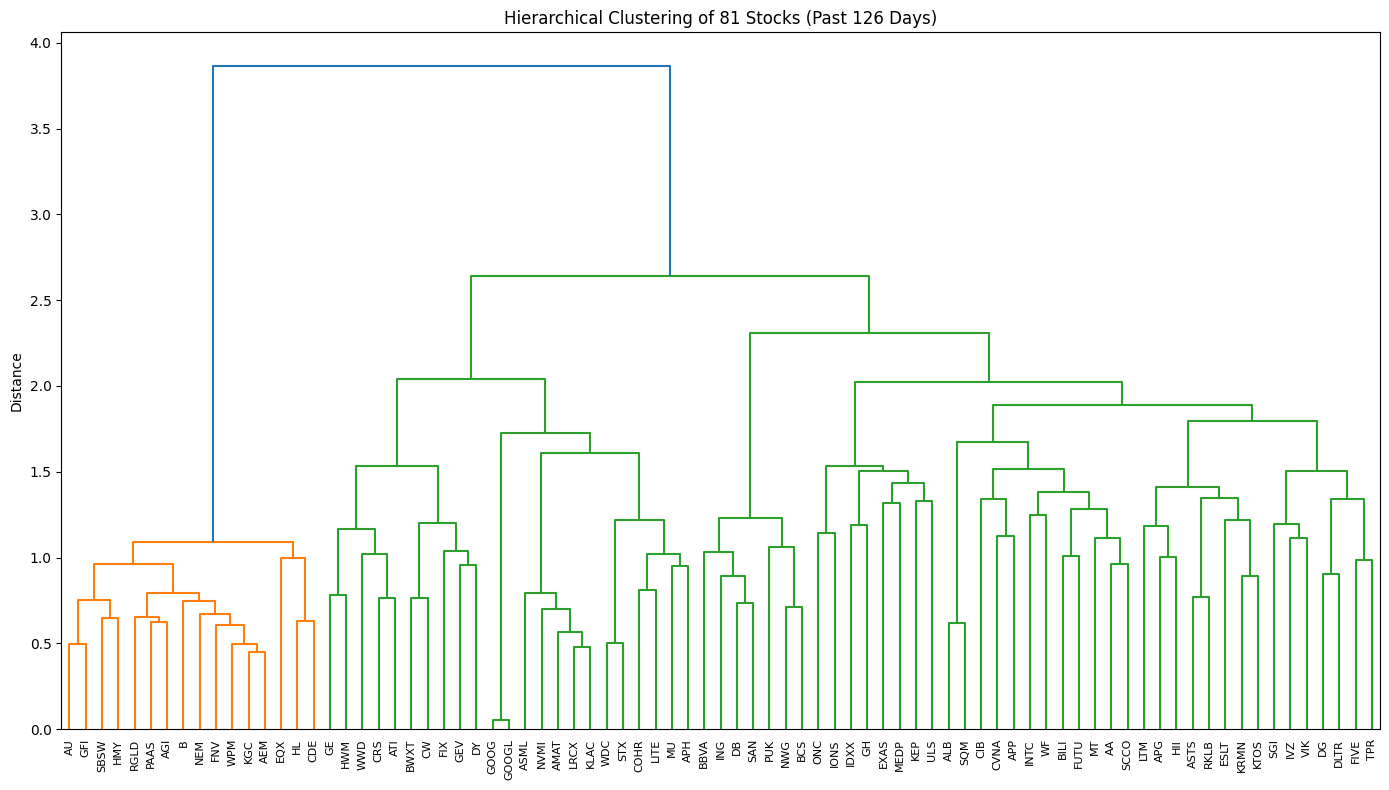


Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):

Cluster 1 (16 stocks): B, AU, SBSW, KGC, FNV, GFI, NEM, AEM, WPM, HL, EQX, RGLD, AGI, PAAS, CDE, HMY
Cluster 2 (10 stocks): HWM, GE, DY, ATI, CW, WWD, FIX, BWXT, GEV, CRS
Cluster 3 (9 stocks): GOOG, GOOGL, APH, KLAC, STX, LITE, MU, AMAT, COHR
Cluster 4 (7 stocks): PUK, SAN, BBVA, ING, BCS, DB, NWG
Cluster 5 (33 stocks): MT, CIB, IONS, WF, LTM, FIVE, IVZ, KEP, APG, ESLT, MEDP, TPR, VIK, HII, SGI, DLTR, ONC, FUTU, IDXX, DG, SCCO, ULS, APP, GH, SQM, INTC, CVNA, BILI, ASTS, EXAS, ALB, RKLB, KRMN


In [18]:
# === Parameters ===
days_per_week = 5  # Trading days in a week
num_weeks = 52  # Weeks in a year
period_week_zscore = days_per_week * num_weeks  # 1-year lookback for weekly return z-score
period_pca = 126  # 6-month lookback for PCA clustering
period_mom_short = 21  # 1-month short-term momentum
period_mom_long = 252  # 1-year long-term momentum
period_vol = 60  # 3-month volatility window
num_clusters = 5  # Number of clusters for hierarchical grouping

# === Fetch Price Data ===
# Download historical closing prices for all stocks
price_data = {}
for stock in tqdm(stocks, desc="Fetching price data"):
    df = get_df(stock, current_date)
    price_data[stock] = df["Close"]

# === Weekly Returns Z-Score Analysis ===
# Z-score measures how unusual this week's return is vs historical weekly returns
# High z-score (>2) = unusually strong week, may indicate temporary spike
df_prices_weekly = pd.DataFrame({stock: price_data[stock].tail(period_week_zscore + days_per_week) for stock in stocks})
weekly_prices = df_prices_weekly.iloc[::days_per_week]  # Sample every 5th day for weekly prices
weekly_returns = weekly_prices.pct_change().dropna()

mean_return = weekly_returns.mean()  # Average weekly return per stock
std_return = weekly_returns.std()  # Weekly return volatility per stock
recent_return = weekly_returns.iloc[-1]  # Most recent week's return
z_scores = (recent_return - mean_return) / std_return  # Standardized deviation from mean

# === Momentum and Volatility Analysis ===
# Momentum: price ratio (recent / year-ago) - measures trend strength over 1 year
# Volatility: standard deviation of daily returns - measures price variability
# Vol-adj Momentum: momentum / volatility - risk-adjusted trend
momentum_list = []
volatility_list = []

for stock in tqdm(stocks, desc="Calculating momentum and volatility"):
    close = price_data[stock]
    momentum = close.iloc[- period_mom_short] / close.iloc[- period_mom_long] if len(close) >= period_mom_long else np.nan
    volatility = close.pct_change().tail(period_vol).std()
    momentum_list.append(momentum)
    volatility_list.append(volatility)

# === Hierarchical Clustering Analysis ===
# Groups stocks by return correlation using Ward's linkage (minimizes within-cluster variance)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

df_prices_cluster = pd.DataFrame({stock: price_data[stock].tail(period_pca) for stock in stocks})
returns = df_prices_cluster.pct_change().dropna()
corr_matrix = returns.corr()  # Pairwise correlation of daily returns
dist_matrix = np.sqrt(2 * (1 - corr_matrix))  # Convert correlation to distance (0=identical, 2=opposite)
condensed_dist = squareform(dist_matrix, checks=False)
Z = linkage(condensed_dist, method="ward")  # Hierarchical clustering linkage matrix
cluster_labels = fcluster(Z, t=num_clusters, criterion="maxclust")

# === Combine All Metrics into Single DataFrame ===
df_combined = pd.DataFrame({
    "Stock": stocks,
    "Cluster": cluster_labels,
    "Momentum": momentum_list,
    "Volatility": volatility_list,
    "Mean Weekly Return (%)": (mean_return * 100).values,
    "Std Weekly Return (%)": (std_return * 100).values,
    "This Week Return (%)": (recent_return * 100).values,
    "Z-Score": z_scores.values
})
df_combined["Vol-adj Momentum"] = df_combined["Momentum"] / df_combined["Volatility"]
df_combined = df_combined.sort_values("Vol-adj Momentum", ascending=False).reset_index(drop=True)
df_combined = df_combined.set_index(df_combined.index + 1)  # 1-based ranking
df_combined.index.name = "Rank"

# === Display Combined DataFrame ===
pd.set_option("display.max_rows", None)
display(df_combined)

# === Dendrogram Visualization ===
# Visual representation of hierarchical clustering - closer stocks are more correlated
plt.figure(figsize=(14, 8))
dendrogram(Z, labels=stocks, leaf_rotation=90, leaf_font_size=8)
plt.title(f"Hierarchical Clustering of {len(stocks)} Stocks (Past {period_pca} Days)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# === Filter and Display Stocks by Cluster ===
# Exclude stocks with z-score > 2 (unusually high recent returns)
# These may be experiencing unsustainable spikes rather than steady momentum
df_filtered = df_combined[df_combined["Z-Score"] <= 2]

print("\nStocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):\n")
for cluster_id in sorted(df_filtered["Cluster"].unique()):
    cluster_df = df_filtered[df_filtered["Cluster"] == cluster_id].sort_values(
        "Vol-adj Momentum", ascending=False
    )
    cluster_stocks = cluster_df["Stock"].tolist()
    print(f"Cluster {cluster_id} ({len(cluster_df)} stocks): {', '.join(cluster_stocks)}")

In [14]:
# === Select Top Stock from Each Cluster ===
# Get the highest rank stock from each cluster (already sorted by Vol-adj Momentum)
top_stocks_per_cluster = df_combined.groupby("Cluster").first().reset_index()

# === Calculate Inverse Volatility Weights ===
top_stocks = top_stocks_per_cluster["Stock"].tolist()
volatilities = np.array(top_stocks_per_cluster["Volatility"])

inv_vol = 1 / volatilities
weights = inv_vol / inv_vol.sum()

# === Display Portfolio Allocation ===
result_df = pd.DataFrame({
    "Cluster": top_stocks_per_cluster["Cluster"],
    "Stock": top_stocks,
    "Volatility": volatilities,
    "Weight (%)": weights * 100
})
display(result_df)

,Cluster,Stock,Volatility,Weight (%)
0,1,B,0.028902,11.639806
1,2,HWM,0.016756,20.076577
2,3,GOOG,0.018023,18.665686
3,4,PUK,0.011713,28.721543
4,5,MT,0.016099,20.896388
